In [38]:
!pip3 install statannotations

In [3]:
!pip3 install scikit-learn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 30.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [scikit-learn] [scikit-learn]


In [6]:
import sklearn
import pandas as pd
import numpy as np
from scipy.stats import wilcoxon
import matplotlib.pyplot as plt
import seaborn as sns

from statannotations.Annotator import Annotator

In [7]:
# Load files
bin_file = "data/fold_test_bin_attn_4concept.csv"
cat_file = "data/fold_test_cat_attn_4concept.csv"

df_bin = pd.read_csv(bin_file)
df_cat = pd.read_csv(cat_file)

# Subset lambda=1
#df_bin = df_bin[df_bin["lambda"] == 1]
#df_cat = df_cat[df_cat["lambda"] == 1]

# --- Parse concepts ---
# Bin: average 4 (Stage), 3 (Age), 10 (Cancer)
def split_bin_concepts(row):
    vals = [float(x) for x in row.strip("[]").split(",")]
    stage = np.mean(vals[:4])
    age = np.mean(vals[4:7])
    cancer = np.mean(vals[7:17])
    return stage, age, cancer

bin_concepts = df_bin["concepts"].apply(split_bin_concepts)
df_bin[["stage_f1","age_f1","cancer_f1",]] = pd.DataFrame(bin_concepts.tolist(), index=df_bin.index)

# Cat: parse 3 values directly
def split_cat_concepts(row):
    vals = [float(x) for x in row.strip("[]").split(",")]
    return vals

cat_concepts = df_cat["concepts"].apply(split_cat_concepts)
df_cat[["stage_f1","age_f1","cancer_f1"]] = pd.DataFrame(cat_concepts.tolist(), index=df_cat.index)

# --- Average across repeats within folds ---
def avg_within_folds(df, model_type):
    grouped = df.groupby("fold").agg({
        "task_f1s":"mean",
        "stage_f1":"mean",
        "age_f1":"mean",
        "cancer_f1":"mean"
    }).reset_index()
    grouped["model"] = model_type
    return grouped

ValueError: Columns must be same length as key

In [ ]:
bin_avg = avg_within_folds(df_bin, "Bin")
cat_avg = avg_within_folds(df_cat, "Cat")

In [3]:
# Combine
df_avg = pd.concat([bin_avg, cat_avg])

# Reshape for plotting
df_melt = df_avg.melt(id_vars=["fold","model"],
                      value_vars=["task_f1s","stage_f1","age_f1","cancer_f1"],
                      var_name="metric", value_name="f1")

## --- Stats ---
#results = []
#for metric in ["task_f1s","stage_f1","age_f1","cancer_f1"]:
#    bin_vals = bin_avg[metric].values
#    cat_vals = cat_avg[metric].values
#    p = wilcoxon(cat_vals, bin_vals).pvalue
#    results.append({"metric":metric, "bin_mean":bin_vals.mean(), "cat_mean":cat_vals.mean(), "p_value":p})


pairs = [(("Task (Survival)","Bin"),("Task (Survival)","Cat")),
         (("Stage","Bin"),("Stage","Cat")),
         (("Age","Bin"),("Age","Cat")),
         (("Cancer","Bin"),("Cancer","Cat"))]

stats_df = pd.DataFrame(results)

metric_labels = {
    "task_f1s": "Task (Survival)",
    "stage_f1": "Stage",
    "age_f1": "Age",
    "cancer_f1": "Cancer"
}
df_melt["metric_label"] = df_melt["metric"].map(metric_labels)
stats_df["metric_label"] = stats_df["metric"].map(metric_labels)

NameError: name 'bin_avg' is not defined

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Stage_Bin vs. Stage_Cat: Wilcoxon test (paired samples), P_val:7.812e-03 Stat=0.000e+00
Task (Survival)_Bin vs. Task (Survival)_Cat: Wilcoxon test (paired samples), P_val:9.453e-01 Stat=1.700e+01
Age_Bin vs. Age_Cat: Wilcoxon test (paired samples), P_val:7.812e-03 Stat=0.000e+00
Cancer_Bin vs. Cancer_Cat: Wilcoxon test (paired samples), P_val:7.812e-03 Stat=0.000e+00


/var/folders/wj/bwk4b7356cn68vctc2ddsfhh0000gr/T/ipykernel_30656/1491419490.py:11: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:w'` for the same effect.

  sns.stripplot(data=df_melt, x="metric_label", y="f1", hue="model",


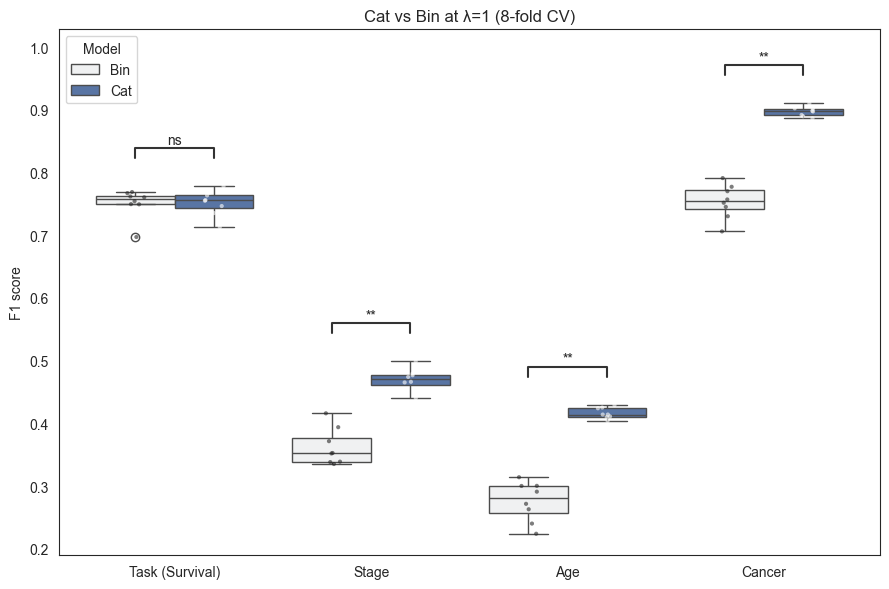

In [54]:
# --- Plot aesthetics ---
sns.set_style("white")
pal = sns.light_palette("#4c72b0", n_colors=2) 


# --- Boxplot ---
plt.figure(figsize=(9,6))
ax = sns.boxplot(data=df_melt, x="metric_label", y="f1", hue="model",
            showcaps=True,
            palette=pal)
sns.stripplot(data=df_melt, x="metric_label", y="f1", hue="model",
                dodge=True, color="w", alpha=0.6, size=3, ax=ax, legend=False)

annotator = Annotator(ax, pairs, data=df_melt, x="metric_label", y="f1", hue="model")
annotator.configure(test='Wilcoxon', text_format='star', loc='inside')
annotator.apply_and_annotate()

plt.title("Cat vs Bin at λ=1 (8-fold CV)")
plt.ylabel("F1 score")
plt.xlabel("")
plt.legend(title="Model")
plt.tight_layout()
plt.show()

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Stage_Bin vs. Stage_Cat: Wilcoxon test (paired samples), P_val:7.812e-03 Stat=0.000e+00
Task (Survival)_Bin vs. Task (Survival)_Cat: Wilcoxon test (paired samples), P_val:9.453e-01 Stat=1.700e+01
Age_Bin vs. Age_Cat: Wilcoxon test (paired samples), P_val:7.812e-03 Stat=0.000e+00
Cancer_Bin vs. Cancer_Cat: Wilcoxon test (paired samples), P_val:7.812e-03 Stat=0.000e+00


/var/folders/wj/bwk4b7356cn68vctc2ddsfhh0000gr/T/ipykernel_30656/4197732655.py:8: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:w'` for the same effect.

  sns.stripplot(data=df_melt, x="metric_label", y="f1", hue="model",


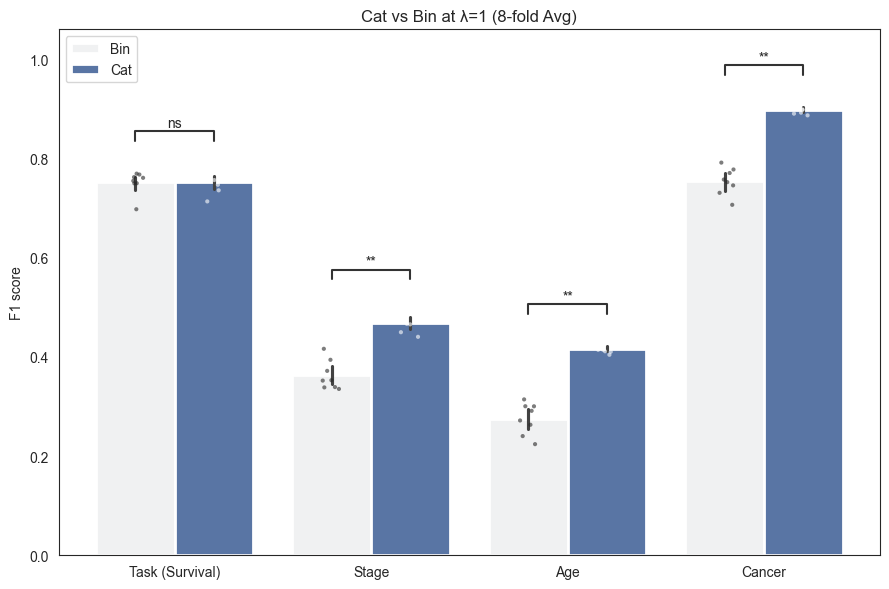

In [61]:
# --- Barplot ---
plt.figure(figsize=(9,6))

pal = sns.light_palette("#4c72b0", n_colors=2) 
ax = sns.barplot(data=df_melt, x="metric_label", y="f1", hue="model",
            palette=pal, linewidth=2)

sns.stripplot(data=df_melt, x="metric_label", y="f1", hue="model",
                dodge=True, color="w", alpha=0.6, size=3, ax=ax, legend=False)

annotator = Annotator(ax, pairs, data=df_melt, x="metric_label", y="f1", hue="model")
annotator.configure(test='Wilcoxon', text_format='star', loc='inside')
annotator.apply_and_annotate()

plt.title("Cat vs Bin at λ=1 (8-fold Avg)")
plt.ylabel("F1 score")
plt.xlabel("")
plt.legend(title="")
plt.tight_layout()
plt.savefig('barplot_stageagecancer.png')
plt.show()